# German Electricity Demand Forecasting

## Part 2: Stationarity Analysis

This notebook investigates the stationarity properties of the weekly German electricity demand series using visualisation, seasonal decomposition, statistical tests and differencing techniques.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

import warnings
warnings.filterwarnings("ignore")

In [9]:
weekly_load = pd.read_csv(
    "/content/weekly_load.csv",
    parse_dates=["timestamp"],
    index_col="timestamp"
)

weekly_load.head()

,load
timestamp,
2015-01-04 00:00:00+00:00,47233.739583
2015-01-11 00:00:00+00:00,56191.101190
2015-01-18 00:00:00+00:00,57672.678571
2015-01-25 00:00:00+00:00,58613.303571
2015-02-01 00:00:00+00:00,58734.029762


## Weekly Electricity Demand Series

Load the aggregated weekly electricity demand series for stationarity assessment and model preparation.

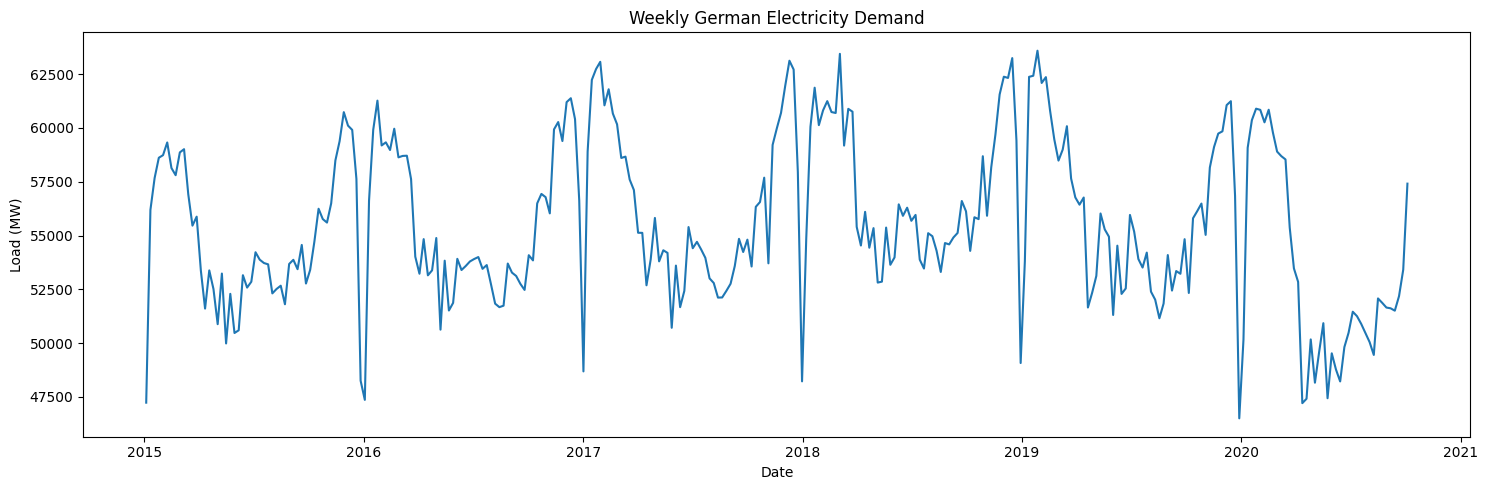

In [10]:
plt.figure(figsize=(15,5))

plt.plot(
    weekly_load.index,
    weekly_load["load"]
)

plt.title(
    "Weekly German Electricity Demand"
)

plt.xlabel("Date")
plt.ylabel("Load (MW)")

plt.tight_layout()

plt.savefig(
    "weekly_series.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

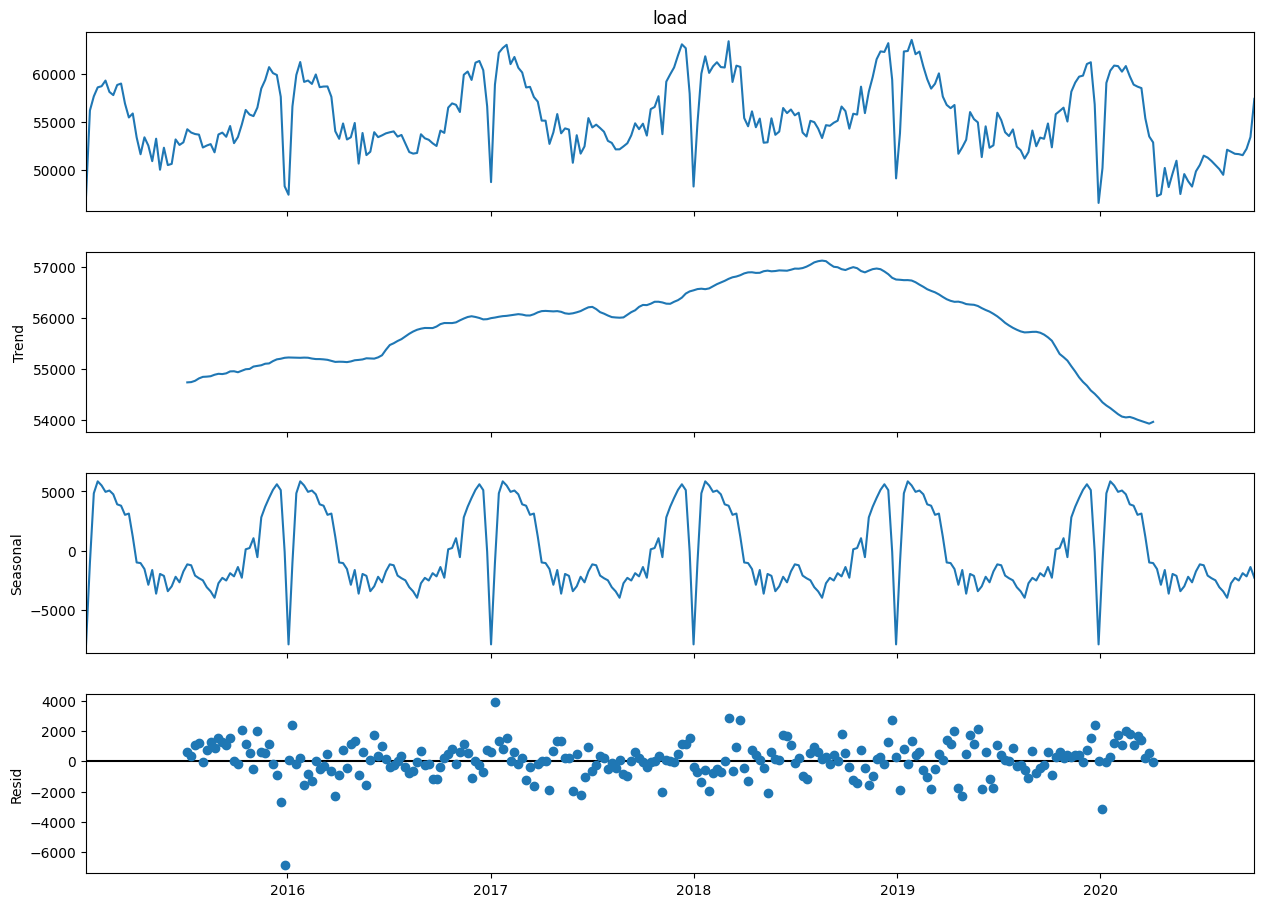

In [11]:
decomposition = seasonal_decompose(
    weekly_load["load"],
    model="additive",
    period=52
)

fig = decomposition.plot()
fig.set_size_inches(14,10)

plt.savefig(
    "seasonal_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Seasonal Decomposition

The weekly electricity demand series is decomposed into trend, seasonal and residual components to identify underlying temporal structure.

## Augmented Dickey-Fuller (ADF) Test

The ADF test is used to determine whether the weekly electricity demand series contains a unit root. The null hypothesis is that the series is non-stationary.

In [12]:
adf_result = adfuller(
    weekly_load["load"]
)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

for key, value in adf_result[4].items():
    print(f"Critical Value ({key}): {value}")

ADF Statistic: -4.047471855678481
p-value: 0.0011813497340154584
Critical Value (1%): -3.4529449243622383
Critical Value (5%): -2.871489553425686
Critical Value (10%): -2.572071437887033


## KPSS Test

The KPSS test is used as a complementary stationarity test. The null hypothesis is that the series is stationary.

In [13]:
kpss_result = kpss(
    weekly_load["load"],
    regression="c"
)

print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])

for key, value in kpss_result[3].items():
    print(f"Critical Value ({key}): {value}")

KPSS Statistic: 0.16037407809773105
p-value: 0.1
Critical Value (10%): 0.347
Critical Value (5%): 0.463
Critical Value (2.5%): 0.574
Critical Value (1%): 0.739
